<a href="https://www.kaggle.com/code/simarbirsinghsandhu/catboost-gpu-fe-encoding?scriptVersionId=325949035" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🌌 Stellar Classification | CatBoost GPU
## Playground Series S6E6
### 🏆 OOF Balanced Accuracy: 0.96746 | 📊 Public LB: 0.96582

⚡ CatBoost + Optuna (GPU) | 5-Fold Stratified CV

**What's in this notebook:**
- Color indices & redshift transforms from EDA findings
- Original SDSS dataset incorporated with domain gap flag
- `spectral_type × galaxy_population` interaction feature
- 3D sphere coordinates from (α, δ)
- Optuna tuning with toggle — skip or run
- OOF predictions saved as `catboost_oof.csv` — ready for blending

Upvote if useful 🙌 | [EDA Deep-Dive](https://www.kaggle.com/code/simarbirsinghsandhu/deep-dive-eda-deepdive-s6e6)

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import catboost as cb
import optuna
import matplotlib.pyplot as plt
import warnings

from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f"CatBoost version: {cb.__version__}")

CatBoost version: 1.2.10


## 2. Config

In [2]:
CONFIG = {
    "train_path"       : "/kaggle/input/competitions/playground-series-s6e6/train.csv",
    "test_path"        : "/kaggle/input/competitions/playground-series-s6e6/test.csv",
    "orig_path"        : "/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv",
    "target_col"       : "class",
    "id_col"           : "id",
    "n_folds"          : 5,
    "seed"             : 42,
    "optuna_trials"    : 50,
    "optuna_folds"     : 3,
    "optuna_subsample" : 200_000,
    "run_optuna"       : False,   # ← toggle True to run Optuna
    "use_original"     : True,    # ← toggle False to exclude SDSS
}

## 3. Load Data

In [3]:
train = pd.read_csv(CONFIG["train_path"])
test  = pd.read_csv(CONFIG["test_path"])
orig  = pd.read_csv(CONFIG["orig_path"])

print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")
print(f"Orig  : {orig.shape}")
print(f"\nClass distribution:")
print(train[CONFIG["target_col"]].value_counts())
print(train[CONFIG["target_col"]].value_counts(normalize=True).round(4))

Train : (577347, 12)
Test  : (247435, 11)
Orig  : (100000, 18)

Class distribution:
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64
class
GALAXY    0.6538
QSO       0.2029
STAR      0.1433
Name: proportion, dtype: float64


## 4. Feature Engineering

Key features from EDA:
- **Color indices** — u−g, g−r, r−i, i−z, u−r, g−z separate classes in photometric space
- **Redshift transforms** — log1p and squared redshift help with the skewed distribution
- **3D coordinates** — converts (α, δ) to (x, y, z) on unit sphere, better than raw angles for trees
- **st_gp interaction** — spectral_type × galaxy_population combo, more informative than either alone
- **Redshift zone flag** — hard zone (0.05–0.25) where color indices do the heavy lifting

In [4]:
def engineer_features(df, is_orig=False):
    df = df.copy()

    # Color indices
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_r'] = df['u'] - df['r']
    df['g_z'] = df['g'] - df['z']
    df['u_z'] = df['u'] - df['z']
    df['r_z'] = df['r'] - df['z']

    # Photometric aggregates
    filters = ['u', 'g', 'r', 'i', 'z']
    df['filter_mean']  = df[filters].mean(axis=1)
    df['filter_std']   = df[filters].std(axis=1)
    df['filter_range'] = df[filters].max(axis=1) - df[filters].min(axis=1)

    # Redshift transforms
    df['log_redshift'] = np.log1p(df['redshift'].clip(lower=0))
    df['redshift_sq']  = df['redshift'] ** 2

    # Hard zone flag (EDA: 118K ambiguous rows here)
    df['is_hard_zone'] = (
        (df['redshift'] >= 0.05) & (df['redshift'] <= 0.25)
    ).astype(np.int8)

    # 3D unit sphere coordinates
    alpha_rad = np.radians(df['alpha'])
    delta_rad = np.radians(df['delta'])
    df['coord_x'] = np.cos(delta_rad) * np.cos(alpha_rad)
    df['coord_y'] = np.cos(delta_rad) * np.sin(alpha_rad)
    df['coord_z'] = np.sin(delta_rad)

    # Categorical interaction
    if 'spectral_type' in df.columns and 'galaxy_population' in df.columns:
        df['st_gp'] = (
            df['spectral_type'].astype(str) + '_' +
            df['galaxy_population'].astype(str)
        )
    
    # Domain gap flag
    df['is_original'] = int(is_orig)

    return df

train = engineer_features(train, is_orig=False)
test  = engineer_features(test,  is_orig=False)
orig  = engineer_features(orig,  is_orig=True)

print(f"Features after engineering: {train.shape[1]}")
print(f"New features: {[c for c in train.columns if c not in ['id','class','alpha','delta','u','g','r','i','z','redshift','spectral_type','galaxy_population']]}")

Features after engineering: 31
New features: ['u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'g_z', 'u_z', 'r_z', 'filter_mean', 'filter_std', 'filter_range', 'log_redshift', 'redshift_sq', 'is_hard_zone', 'coord_x', 'coord_y', 'coord_z', 'st_gp', 'is_original']


## 5. Preprocessing

In [5]:
CAT_COLS  = ['spectral_type', 'galaxy_population', 'st_gp']

DROP_COLS = ['id', 'class']

for col in CAT_COLS:
    train[col] = train[col].astype(str)
    test[col]  = test[col].astype(str)

CLASS_MAP         = {'GALAXY': 0, 'QSO': 1, 'STAR': 2}
CLASS_MAP_INVERSE = {0: 'GALAXY', 1: 'QSO', 2: 'STAR'}

train['label'] = train['class'].map(CLASS_MAP)

print(f"Class mapping: {CLASS_MAP}")
print(f"Label distribution:\n{train['label'].value_counts().sort_index()}")

if CONFIG["use_original"]:
    for col in CAT_COLS:
        if col not in orig.columns:
            orig[col] = 'Unknown'

    orig['label'] = orig['class'].map(CLASS_MAP)

    FEATURE_COLS = [c for c in train.columns
                    if c not in DROP_COLS + ['label']]

    orig_aligned = orig.reindex(
        columns=FEATURE_COLS + ['label'], fill_value=0
    )
    for col in CAT_COLS:
        orig_aligned[col] = orig_aligned[col].astype(str)

    train_full = pd.concat([train, orig_aligned], ignore_index=True)
    print(f"\nTrain + Orig: {train_full.shape[0]:,} rows")
else:
    train_full = train.copy()
    FEATURE_COLS = [c for c in train.columns
                    if c not in DROP_COLS + ['label']]
    print(f"\nTrain only: {train_full.shape[0]:,} rows")

X_df      = train_full[FEATURE_COLS]
y         = train_full['label'].values
X_test_df = test[FEATURE_COLS]

cat_feature_indices = [
    X_df.columns.get_loc(c)
    for c in CAT_COLS if c in X_df.columns
]

print(f"\nTotal features   : {len(FEATURE_COLS)}")
print(f"Train rows       : {len(X_df):,}")
print(f"Cat features     : {[FEATURE_COLS[i] for i in cat_feature_indices]}")

Class mapping: {'GALAXY': 0, 'QSO': 1, 'STAR': 2}
Label distribution:
label
0    377480
1    117143
2     82724
Name: count, dtype: int64

Train + Orig: 677,347 rows

Total features   : 29
Train rows       : 677,347
Cat features     : ['spectral_type', 'galaxy_population', 'st_gp']


## 6. Optuna Hyperparameter Search

3-fold CV on 150K subsample, optimizing balanced accuracy directly.
Set `CONFIG["run_optuna"] = True` to run.

In [6]:
def run_optuna(X_df, y, cat_indices, cfg):
    rng   = np.random.RandomState(cfg["seed"])
    idx   = rng.choice(len(X_df),
                       min(cfg["optuna_subsample"], len(X_df)),
                       replace=False)
    X_opt = X_df.iloc[idx].reset_index(drop=True)
    y_opt = y[idx]
    print(f"Subsampled to {len(X_opt):,} rows for Optuna")

    kf = StratifiedKFold(n_splits=cfg["optuna_folds"],
                         shuffle=True, random_state=cfg["seed"])

    def objective(trial):
        params = {
            "iterations"          : 4000,
            "learning_rate"       : trial.suggest_float("learning_rate",       0.05, 0.15,  log=True),
            "depth"               : trial.suggest_int(  "depth",               4,    8),
            "l2_leaf_reg"         : trial.suggest_float("l2_leaf_reg",         1.0,  10.0,  log=True),
            "bagging_temperature" : trial.suggest_float("bagging_temperature", 0.0,  1.0),
            "random_strength"     : trial.suggest_float("random_strength",     0.0,  2.0),
            "border_count"        : trial.suggest_int(  "border_count",        64,   255),
            "task_type"           : "GPU",
            "loss_function"       : "MultiClass",
            "eval_metric"         : "TotalF1",
            "auto_class_weights"  : "Balanced",
            "random_seed"         : cfg["seed"],
            "verbose"             : False,
        }

        scores = []
        for tr_idx, va_idx in kf.split(X_opt, y_opt):
            X_tr = X_opt.iloc[tr_idx]
            X_va = X_opt.iloc[va_idx]
            y_tr = y_opt[tr_idx]
            y_va = y_opt[va_idx]

            train_pool = cb.Pool(X_tr, y_tr, cat_features=cat_indices)
            val_pool   = cb.Pool(X_va, y_va, cat_features=cat_indices)

            model = cb.CatBoostClassifier(**params)
            model.fit(train_pool,
                      eval_set=val_pool,
                      early_stopping_rounds=100,
                      verbose=False)

            preds = model.predict(X_va).ravel()
            scores.append(balanced_accuracy_score(y_va, preds))

        return np.mean(scores)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=cfg["seed"])
    )
    study.optimize(objective,
                   n_trials=cfg["optuna_trials"],
                   show_progress_bar=True)

    print(f"\n✅ Best balanced acc : {study.best_value:.6f}")
    print(f"Best params:\n{study.best_params}")
    return study.best_params, study


if CONFIG["run_optuna"]:
    best_params, study = run_optuna(
        X_df, y, cat_feature_indices, CONFIG
    )
else:
    print("Optuna skipped — using preset best_params.")
    print("Set CONFIG['run_optuna'] = True to tune.")

Optuna skipped — using preset best_params.
Set CONFIG['run_optuna'] = True to tune.


## 7. Best Params

Pre-filled from Optuna run. If you ran Optuna above, `best_params` is already set.

In [7]:
if not CONFIG["run_optuna"]:
    best_params = {
        "learning_rate"      : 0.07,
        "depth"              : 6,
        "l2_leaf_reg"        : 4.65,
        "random_strength"    : 0.19,
        "bagging_temperature": 0.30,
        "border_count"       : 255,
    }

print("Using params:", best_params)

Using params: {'learning_rate': 0.07, 'depth': 6, 'l2_leaf_reg': 4.65, 'random_strength': 0.19, 'bagging_temperature': 0.3, 'border_count': 255}


## 8. OOF Training

Full 5-fold stratified CV.
- `loss_function = MultiClass` — proper multiclass objective
- `eval_metric = TotalF1` — directly optimizes per-class F1, helps minority STAR class
- `auto_class_weights = Balanced` — compensates for GALAXY dominance (65.4%)
- Early stopping on 500 rounds

In [8]:
def catboost_oof(X_df, y, X_test_df, cat_indices, params, cfg):
    kf         = StratifiedKFold(n_splits=cfg["n_folds"],
                                 shuffle=True, random_state=cfg["seed"])
    n_classes  = len(np.unique(y))
    oof_labels = np.zeros(len(X_df), dtype=int)
    oof_probs  = np.zeros((len(X_df), n_classes))
    test_probs = np.zeros((len(X_test_df), n_classes))
    fold_scores = []

    run_params = {
        "iterations"         : 6000,
        "task_type"          : "GPU",
        "loss_function"      : "MultiClass",
        "eval_metric"        : "TotalF1",
        "auto_class_weights" : "Balanced",
        "random_seed"        : cfg["seed"],
        "allow_writing_files": False,
        "verbose"            : 500,
        **params,
    }

    test_pool = cb.Pool(X_test_df, cat_features=cat_indices)

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_df, y)):
        print(f"\n{'='*45}")
        print(f"  FOLD {fold+1} / {cfg['n_folds']}")
        print(f"{'='*45}")

        X_tr = X_df.iloc[tr_idx]
        X_va = X_df.iloc[va_idx]
        y_tr = y[tr_idx]
        y_va = y[va_idx]

        train_pool = cb.Pool(X_tr, y_tr, cat_features=cat_indices)
        val_pool   = cb.Pool(X_va, y_va, cat_features=cat_indices)

        model = cb.CatBoostClassifier(**run_params)
        model.fit(train_pool,
                  eval_set=val_pool,
                  early_stopping_rounds=500,
                  use_best_model=True,
                  verbose=200)

        val_labels            = model.predict(X_va).ravel()
        val_probs             = model.predict_proba(X_va)
        oof_labels[va_idx]    = val_labels
        oof_probs[va_idx]     = val_probs
        test_probs           += model.predict_proba(X_test_df) / cfg["n_folds"]

        score = balanced_accuracy_score(y_va, val_labels)
        fold_scores.append(score)
        print(f"\n  Fold {fold+1} Balanced Accuracy: {score:.5f}")

    oof_score = balanced_accuracy_score(y, oof_labels)

    print(f"\n{'─'*45}")
    for i, s in enumerate(fold_scores):
        print(f"  Fold {i+1}: {s:.5f}")
    print(f"{'─'*45}")
    print(f"  Mean : {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print(f"  OOF  : {oof_score:.5f}")
    print(f"{'─'*45}")

    return oof_labels, oof_probs, test_probs, fold_scores, oof_score, model


oof_labels, oof_probs, test_probs, fold_scores, oof_score, last_model = catboost_oof(
    X_df, y, X_test_df, cat_feature_indices, best_params, CONFIG
)


  FOLD 1 / 5
0:	learn: 0.9156635	test: 0.9139191	best: 0.9139191 (0)	total: 9.33s	remaining: 15h 32m 32s
200:	learn: 0.9604164	test: 0.9600065	best: 0.9600544 (199)	total: 12.1s	remaining: 5m 49s
400:	learn: 0.9640302	test: 0.9632706	best: 0.9633418 (387)	total: 14.9s	remaining: 3m 28s
600:	learn: 0.9661889	test: 0.9646776	best: 0.9647268 (590)	total: 17.7s	remaining: 2m 39s
800:	learn: 0.9677381	test: 0.9655210	best: 0.9655210 (800)	total: 20.5s	remaining: 2m 13s
1000:	learn: 0.9688544	test: 0.9662265	best: 0.9662497 (999)	total: 23.3s	remaining: 1m 56s
1200:	learn: 0.9697174	test: 0.9665661	best: 0.9666070 (1192)	total: 26.1s	remaining: 1m 44s
1400:	learn: 0.9705606	test: 0.9669160	best: 0.9669319 (1397)	total: 28.9s	remaining: 1m 34s
1600:	learn: 0.9712547	test: 0.9669431	best: 0.9670526 (1537)	total: 31.6s	remaining: 1m 26s
1800:	learn: 0.9717942	test: 0.9671528	best: 0.9671528 (1800)	total: 34.3s	remaining: 1m 20s
2000:	learn: 0.9724119	test: 0.9670703	best: 0.9671528 (1800)	tota

## 9. Save OOF

In [9]:
train_ids = train_full['id'].values if 'id' in train_full.columns \
            else np.arange(len(oof_labels))

oof_df = pd.DataFrame({
    "id"          : train_ids,
    "y_true"      : y,                # integers: 0=GALAXY 1=QSO 2=STAR
    "oof_pred"    : oof_labels,       # integers
    "prob_GALAXY" : oof_probs[:, 0],
    "prob_QSO"    : oof_probs[:, 1],
    "prob_STAR"   : oof_probs[:, 2],
})
oof_df.to_csv("catboost_oof.csv", index=False)
print(f"✅ OOF saved → catboost_oof.csv  ({len(oof_df):,} rows)")
print(f"   OOF Balanced Accuracy: {oof_score:.5f}")
print(f"   Mapping: {CLASS_MAP}")

✅ OOF saved → catboost_oof.csv  (677,347 rows)
   OOF Balanced Accuracy: 0.96746
   Mapping: {'GALAXY': 0, 'QSO': 1, 'STAR': 2}


## 10. Submission

In [10]:
submission = pd.read_csv(
    '/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv'
)
submission['class'] = pd.Series(
    test_probs.argmax(axis=1)
).map(CLASS_MAP_INVERSE)

submission.to_csv('submission.csv', index=False)

print("✅ Submission saved")
print(f"   Shape : {submission.shape}")
print(f"\nPrediction distribution:")
print(submission['class'].value_counts())
print(submission['class'].value_counts(normalize=True).round(4))
print(submission.head())

✅ Submission saved
   Shape : (247435, 2)

Prediction distribution:
class
GALAXY    157095
QSO        51384
STAR       38956
Name: count, dtype: int64
class
GALAXY    0.6349
QSO       0.2077
STAR      0.1574
Name: proportion, dtype: float64
       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY


## 11. Feature Importance

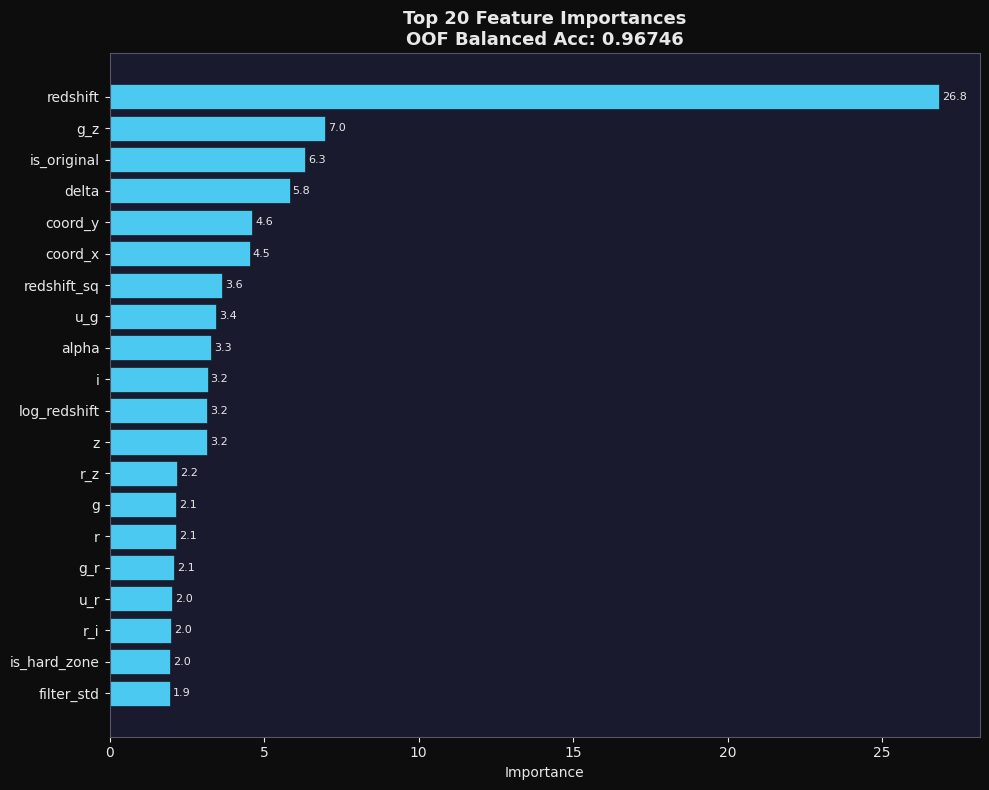

In [11]:
fi = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': last_model.get_feature_importance()
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8), facecolor='#0d0d0d')
ax.set_facecolor('#1a1a2e')

bars = ax.barh(fi['feature'], fi['importance'],
               color='#4cc9f0', edgecolor='#0d0d0d', linewidth=0.4)

for bar, val in zip(bars, fi['importance']):
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', color='#e8e8e8', fontsize=8)

ax.set_title(f'Top 20 Feature Importances\nOOF Balanced Acc: {oof_score:.5f}',
             color='#e8e8e8', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance', color='#e8e8e8')
ax.tick_params(colors='#e8e8e8')
for spine in ax.spines.values():
    spine.set_edgecolor('#555566')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

## Summary

| | Score |
|---|---|
| OOF Balanced Accuracy | 0.96746 |
| Public LB | 0.96582 |

**Why CatBoost for this problem:**
- Native categorical handling for `spectral_type`, `galaxy_population`, `st_gp` — no label encoding artifacts
- `auto_class_weights = Balanced` directly addresses the GALAXY/STAR imbalance (65% vs 14%)
- `TotalF1` eval metric optimizes per-class F1 — the minority STAR class gets proper attention
- Ordered boosting gives a different bias-variance tradeoff vs LGBM/XGB — blending all three helps

**Next step — blend CatBoost + LGBM + XGB OOFs for best LB score**

Upvote if useful 🙌 | [EDA Deep-Dive](https://www.kaggle.com/code/simarbirsinghsandhu/deep-dive-eda-deepdive-s6e6)